# Navigare negli anime: trovare quello che fa per te in un catalogo sconfinato

Negli ultimi vent'anni, il numero di anime prodotti ogni anno è cresciuto in modo esponenziale. Oggi MyAnimeList cataloga quasi 29.000 titoli, un numero talmente alto da rendere impossibile anche solo sfogliarli tutti. Per un fan, questo non è necessariamente una buona notizia: più contenuto c'è, più diventa difficile trovare quello che vale davvero la pena guardare.

Il problema della scoperta è diventato centrale nell'esperienza del fandom moderno. Non mancano i consigli ma spesso si contraddicono, si sovrappongono, o puntano sempre agli stessi titoli.


MyAnimeList contiene 124 milioni di valutazioni e 105.000 raccomandazioni. Questo notebook usa questi dati per costruire quattro strumenti di navigazione concreti.
- Da dove iniziare?
- Cosa guardare dopo?
- Dove cercare se hai già esaurito i titoli noti?
- Quando farlo, nel calendario delle uscite stagionali?

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

DATA_PATH = '../datasets_cleaned/'

details = pd.read_csv(DATA_PATH + 'details_clean.csv')
stats   = pd.read_csv(DATA_PATH + 'stats_clean.csv')
recs    = pd.read_csv(DATA_PATH + 'recommendations_clean.csv')

# Filtro: solo i tipi rilevanti
TIPI = ['TV', 'Movie', 'OVA', 'ONA']
details = details[details['type'].isin(TIPI)].reset_index(drop=True)
stats   = stats[stats['mal_id'].isin(details['mal_id'])].reset_index(drop=True)
recs    = recs[
    recs['mal_id'].isin(details['mal_id']) &
    recs['recommendation_mal_id'].isin(details['mal_id'])
].reset_index(drop=True)

print('details:', details.shape)
print('stats:  ', stats.shape)
print('recs:   ', recs.shape)
print('Tipi presenti:', sorted(details['type'].unique()))


details: (21609, 28)
stats:   (21609, 27)
recs:    (101422, 2)
Tipi presenti: ['Movie', 'ONA', 'OVA', 'TV']


## I punti di riferimento: dalla mappa dei generi alla Hall of Fame

Ogni navigazione parte da una visione d'insieme. Prima di scegliere un titolo specifico, vale la pena capire com'è fatto il territorio: quanti generi esistono, quanto sono grandi, quanto sono affidabili in termini di qualità media. Solo dopo aver capito la struttura del catalogo ha senso chiedersi: quali sono i titoli migliori al suo interno?

Il grafico che segue mappa tutti i generi su due assi: quanti anime esistono per quel genere (quanto è popolato il territorio) e qual è il loro punteggio medio (quanto è affidabile come zona di esplorazione). Un genere in alto a destra ha molti titoli di alta qualità: è un territorio ricco e consolidato. Un genere in alto a sinistra ha pochi titoli ma molto buoni: è una nicchia preziosa. Per chi vuole allargare la propria mappa, questo grafico mostra dove vale la pena guardare.

In [100]:
import plotly.express as px

det_g = details.dropna(subset=['genres', 'score']).copy()
det_g['genre'] = det_g['genres'].str[2:-2].str.split("', '")
det_g = det_g.explode('genre')
det_g = det_g[det_g['genre'].str.strip() != '']

genre_stats = (
    det_g.groupby('genre')
    .agg(n_titoli=('mal_id', 'count'), score_medio=('score', 'mean'))
    .query('n_titoli >= 30')
    .sort_values('score_medio', ascending=False)
    .reset_index()
)

score_mean = genre_stats['score_medio'].mean()

fig = px.scatter(
    genre_stats,
    x='n_titoli',
    y='score_medio',
    color='score_medio',
    color_continuous_scale='RdYlGn',
    hover_name='genre',
    hover_data={'n_titoli': True, 'score_medio': ':.2f'},
    labels={
        'n_titoli': 'Numero di titoli nel genere',
        'score_medio': 'Score medio MAL',
    },
    title='<b>La mappa dei generi: volume e qualità media per ogni territorio del catalogo</b>',
)

fig.update_traces(
    marker=dict(size=10, line=dict(color='white', width=1)),
)

# Offset custom per i generi sovrapposti, default per gli altri
custom_offsets = {
    'Girls Love':   dict(xshift=-30, yshift=12),
    'Boys Love':    dict(xshift=40,  yshift=12),
    'Gourmet':      dict(xshift=0,   yshift=-18),
    'Ecchi':        dict(xshift=-25, yshift=0),
    'Slice of Life':dict(xshift=40,  yshift=0),
    'Comedy':       dict(xshift=12,  yshift=-10),
}
default_offset = dict(xshift=12, yshift=9)

for _, row in genre_stats.iterrows():
    off = custom_offsets.get(row['genre'], default_offset)
    fig.add_annotation(
        x=row['n_titoli'],
        y=row['score_medio'],
        text=row['genre'],
        showarrow=False,
        font=dict(size=11),
        **off,
    )

fig.add_hline(
    y=score_mean,
    line_dash='dash',
    line_color='grey',
    opacity=0.5,
    annotation_text='score medio globale',
    annotation_position='top right',
    annotation_font_size=11,
    annotation_font_color='grey',
)

fig.update_layout(
    font_size=12,
    title_font_size=14,
    coloraxis_colorbar=dict(title='Score medio'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    height=600,
)

fig.show()


Una volta capita la struttura del territorio, la domanda naturale diventa: quali sono i titoli migliori al suo interno? Due criteri diversi danno risposte diverse.

- Il **punteggio medio** aggrega le valutazioni di migliaia di utenti: misura la qualità percepita dalla massa, ovvero quanti spettatori sono rimasti soddisfatti.
- I **favorites** misurano qualcosa di più viscerale: quante persone hanno deciso che quell'anime merita un posto speciale nel proprio profilo, al di là della valutazione numerica.

Le due classifiche che seguono confrontano i top 10 per punteggio e i top 10 per favorites.

In [101]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

top_score = (
    details
    .query('scored_by >= 10000')
    .nlargest(10, 'score')
    [['title', 'score', 'favorites', 'year']]
    .reset_index(drop=True)
)

top_fav = (
    details
    .nlargest(10, 'favorites')
    [['title', 'favorites', 'score']]
    .reset_index(drop=True)
)

in_both   = set(top_score['title']) & set(top_fav['title'])
n_overlap = len(in_both)

COLOR_BOTH = '#F4863E'  # arancione — appare in entrambe le classifiche
COLOR_SOLO = '#5B8DB8'  # blu — solo in questa classifica

def trunc(t, n=18):
    return t[:n] + '...' if len(t) > n else t

fav_titles_r   = top_fav['title'][::-1].tolist()
fav_values_r   = top_fav['favorites'][::-1].tolist()
score_titles_r = top_score['title'][::-1].tolist()
score_values_r = top_score['score'][::-1].tolist()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        'Top 10 per Favorites',
        'Top 10 per Score',
    ],
    vertical_spacing=0.14,
)

fig.add_trace(go.Bar(
    y=[trunc(t) for t in fav_titles_r],
    x=fav_values_r,
    orientation='h',
    marker_color=[COLOR_BOTH if t in in_both else COLOR_SOLO for t in fav_titles_r],
    hovertext=fav_titles_r,
    hovertemplate='<b>%{hovertext}</b><br>Favorites: %{x:,}<extra></extra>',
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    y=[trunc(t) for t in score_titles_r],
    x=score_values_r,
    orientation='h',
    marker_color=[COLOR_BOTH if t in in_both else COLOR_SOLO for t in score_titles_r],
    hovertext=score_titles_r,
    hovertemplate='<b>%{hovertext}</b><br>Score: %{x:.2f}<extra></extra>',
    showlegend=False,
), row=2, col=1)

# Tracce vuote solo per la legenda
fig.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COLOR_BOTH, name='Appare in più classifiche',
))
fig.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COLOR_SOLO, name='Solo in questa',
))

fig.update_layout(
    height=800,
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.08,
        xanchor='center', x=0.5,
        font_size=12,
    ),
    margin=dict(b=120),
)

fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0', zeroline=False)
fig.update_yaxes(showgrid=False, tickfont_size=11)

# Favorites: asse X parte da 0
fig.update_xaxes(title_text='Numero di Favorites', row=1, col=1)

# Score: asse X parte vicino al minimo per evidenziare le differenze
fig.update_xaxes(
    range=[top_score['score'].min() - 0.3, top_score['score'].max() + 0.15],
    title_text='Score MAL',
    row=2, col=1,
)

fig.show()


La mappa dei generi e la Hall of Fame insieme danno un primo orientamento completo: sappiamo quali territori esistono, qual è la qualità media di ciascuno, e quali titoli rappresentano il meglio in assoluto.

I titoli che compaiono sia nella classifica per punteggio che in quella per favorites sono pochi e questa divergenza è rilevante. Score e favorites misurano fenomeni distinti: il punteggio premia la coerenza qualitativa percepita dal pubblico mentre i favorites misurano l'attaccamento emotivo, quante persone hanno sentito quell'anime come qualcosa di proprio.

Sapere dove si trovano i punti di riferimento è però solo il primo passo. Il vero problema della navigazione emerge subito dopo: adesso che abbiamo visto i titoli al top, come si trova il prossimo anime da guardare in un catalogo di quasi trentamila titoli?

## Navigare per connessioni: le raccomandazioni del fandom

Il modo più naturale di navigare un catalogo enorme è partire da qualcosa che già conosci e ami, e muoversi verso ciò che gli assomiglia. È il principio alla base di qualsiasi motore di raccomandazione.

Su Netflix o Spotify, le raccomandazioni emergono da pattern statistici sul comportamento di milioni di utenti: se chi guarda X tende a guardare anche Y, il sistema li collega. Su MAL, le raccomandazioni sono scritte a mano dagli utenti, con una spiegazione esplicita del perché due anime sono simili: trama analoga, stesso autore, atmosfera simile, protagonisti con caratteristiche comuni.

Il grafico che segue mostra, per un anime di partenza configurabile, quali titoli la community raccomanda più spesso.

In [109]:
import math
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_ego_network(anime_title):
    match = details[details['title'] == anime_title]
    if match.empty:
        print(f'Nessun anime trovato per: {anime_title!r}')
        return

    anime_id   = match.iloc[0]['mal_id']
    anime_name = match.iloc[0]['title']

    fwd    = recs.loc[recs['mal_id'] == anime_id, 'recommendation_mal_id']
    bwd    = recs.loc[recs['recommendation_mal_id'] == anime_id, 'mal_id']
    counts = pd.concat([fwd, bwd]).value_counts().head(12).rename('n_rec')

    rec_df = (
        details
        .loc[details['mal_id'].isin(counts.index), ['mal_id', 'title', 'score', 'year']]
        .set_index('mal_id')
        .assign(n_rec=counts)
        .dropna(subset=['n_rec'])
        .sort_values('n_rec', ascending=False)
        .reset_index()
    )

    if rec_df.empty:
        print(f'Nessuna raccomandazione trovata per: {anime_name!r}')
        return

    n       = len(rec_df)
    angles  = [2 * math.pi * i / n for i in range(n)]
    radius  = 2.5
    rec_x   = [radius * math.cos(a) for a in angles]
    rec_y   = [radius * math.sin(a) for a in angles]

    fig = go.Figure()

    for i in range(n):
        fig.add_trace(go.Scatter(
            x=[0, rec_x[i], None], y=[0, rec_y[i], None],
            mode='lines',
            line=dict(width=2, color='rgba(180,180,180,0.45)'),
            hoverinfo='none', showlegend=False,
        ))

    score_vals = rec_df['score'].fillna(rec_df['score'].mean()).tolist()
    node_sizes = [20] * n
    customdata = [
        [row['title'], f"{row['score']:.2f}" if pd.notna(row['score']) else 'N/A']
        for _, row in rec_df.iterrows()
    ]

    fig.add_trace(go.Scatter(
        x=rec_x, y=rec_y,
        mode='markers+text',
        marker=dict(
            size=node_sizes,
            color=score_vals, colorscale='Blues',
            cmin=min(score_vals), cmax=max(score_vals),
            line=dict(color='white', width=2),
            colorbar=dict(title='Score MAL', thickness=12, len=0.5, x=1.02),
        ),
        text=[t[:15] + '…' if len(t) > 15 else t for t in rec_df['title']],
        textposition='top center', textfont=dict(size=10),
        customdata=customdata,
        hovertemplate='<b>%{customdata[0]}</b><br>Score: %{customdata[1]}<extra></extra>',
        showlegend=False,
    ))

    fig.add_trace(go.Scatter(
        x=[0], y=[0],
        mode='markers+text',
        marker=dict(size=48, color='#F4863E', line=dict(color='white', width=3)),
        text=[anime_name[:20] + '…' if len(anime_name) > 20 else anime_name],
        textposition='bottom center', textfont=dict(size=11),
        hovertemplate=f'<b>{anime_name}</b><br>Anime di partenza<extra></extra>',
        showlegend=False,
    ))

    fig.update_layout(
        title=dict(
            text=f'<b>Rete di raccomandazioni: "{anime_name}"</b><br>',
            x=0.5, font_size=13,
        ),
        height=650,
        plot_bgcolor='white', paper_bgcolor='white',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-4.2, 4.2]),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   range=[-4.2, 4.2], scaleanchor='x'),
        margin=dict(l=20, r=60, t=100, b=20),
    )
    fig.show()


# --- UI ---
search_box = widgets.Text(
    value='Fullmetal Alchemist: Brotherhood',
    placeholder='Digita il titolo (anche parziale)…',
    description='Cerca:',
    layout=widgets.Layout(width='460px'),
    style={'description_width': 'initial'},
)
btn = widgets.Button(description='Cerca', button_style='primary', layout=widgets.Layout(width='100px'))
out = widgets.Output()

def cerca(_):
    query   = search_box.value.strip()
    matches = details[details['title'].str.contains(query, case=False, na=False)]
    with out:
        clear_output(wait=True)
        if matches.empty:
            print(f'Nessun titolo trovato per "{query}"')
        elif len(matches) == 1:
            plot_ego_network(matches.iloc[0]['title'])
        else:
            dd = widgets.Dropdown(
                options=matches['title'].tolist(),
                description='Seleziona:',
                layout=widgets.Layout(width='460px'),
                style={'description_width': 'initial'},
            )
            btn2 = widgets.Button(description='Conferma', button_style='success')
            out2 = widgets.Output()

            def conferma(_):
                with out2:
                    clear_output(wait=True)
                    plot_ego_network(dd.value)

            btn2.on_click(conferma)
            display(widgets.HBox([dd, btn2]), out2)

btn.on_click(cerca)
display(widgets.HBox([search_box, btn]), out)
with out:
    plot_ego_network('Fullmetal Alchemist: Brotherhood')


Output()

La resistenza alla manipolazione di questo sistema è la sua forza principale come strumento di navigazione. Chi scrive una raccomandazione su MAL non ha incentivi commerciali: lo fa perché vuole che altri apprezzino qualcosa che ha amato. Il consenso che emerge — quanti utenti raccomandano indipendentemente la stessa coppia — misura la forza reale della connessione percepita tra i due titoli.

Per usarlo: cambia `INPUT_ANIME` con qualsiasi titolo che hai amato e il grafico mostra la mappa dei passi successivi suggeriti dal fandom. È uno strumento di navigazione personalizzato, costruito da chi ha già percorso quel tratto di catalogo prima di te.

Ma le 105.000 raccomandazioni di MAL non sono solo uno strumento pratico di navigazione: prese collettivamente, formano un **grafo** — un network in cui i nodi sono gli anime e gli archi sono le connessioni tra titoli simili. Analizzare la struttura di questo grafo rivela qualcosa di più profondo sui gusti del pubblico: quali titoli funzionano da hub trasversali, dove si trovano i cluster di gusto, e chi sono i veri ponti culturali tra generi diversi.

### La struttura del grafo delle raccomandazioni

Alcune domande a cui risponde l'analisi strutturale del network:

- Quali anime funzionano da **hub** — titoli raccomandati in decine di contesti diversi, ponti tra generi e stili opposti?
- Il network dei gusti anime ha **cluster identificabili** — comunità di titoli che si raccomandano a vicenda più di quanto raccomandino titoli esterni?
- Chi sono i **veri ponti culturali** — anime consigliati da fan di generi radicalmente diversi?

In [103]:
import networkx as nx
import matplotlib.patches as mpatches

#### Gli anime hub: chi viene raccomandato da tutti?

Il primo indicatore strutturale di un nodo importante in un grafo è il suo **grado** — quante connessioni ha. Nel nostro network, il grado di un anime misura quante volte viene raccomandato come passo successivo per altri titoli. Un anime con grado alto è un hub: viene consigliato da chi ha visto Action, da chi ha visto Romance, da chi ha visto Fantasy. È un titolo che "parla" a pubblici diversi.

Questi hub sono particolarmente interessanti perché non si trovano necessariamente tra gli anime più popolari in senso assoluto — si trovano tra quelli più *trasversali*.

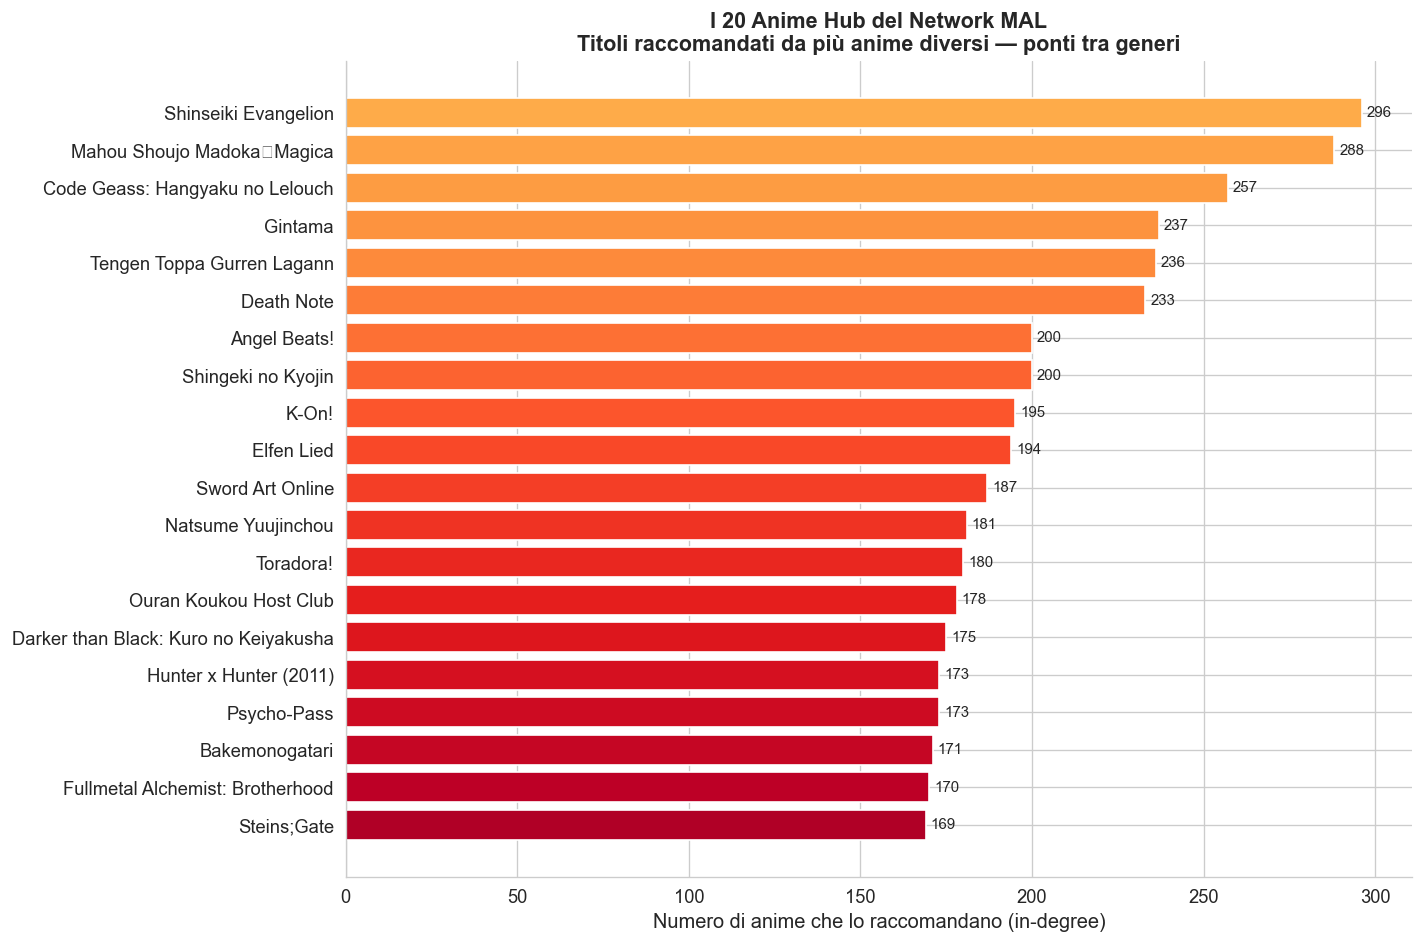


Top 10 hub con score:
                                title  in_degree  out_degree  score
20               Shinseiki Evangelion        296       296.0   8.36
3519       Mahou Shoujo Madoka★Magica        288       288.0   8.38
1160  Code Geass: Hangyaku no Lelouch        257       257.0   8.71
724                           Gintama        237       237.0   8.93
1446       Tengen Toppa Gurren Lagann        236       236.0   8.64
1129                       Death Note        233       233.0   8.62
3023                     Angel Beats!        200       200.0   8.05
4184               Shingeki no Kyojin        200       200.0   8.56
2848                            K-On!        195       195.0   7.86
196                        Elfen Lied        194       194.0   7.46


In [104]:
degree_in  = recs['recommendation_mal_id'].value_counts().reset_index()
degree_in.columns = ['mal_id', 'in_degree']
degree_out = recs['mal_id'].value_counts().reset_index()
degree_out.columns = ['mal_id', 'out_degree']

degree_df = (
    degree_in.merge(degree_out, on='mal_id', how='outer').fillna(0)
    .merge(details[['mal_id', 'title', 'score', 'popularity', 'genres']], on='mal_id', how='left')
)
degree_df['total_degree'] = degree_df['in_degree'] + degree_df['out_degree']

top_hubs = degree_df.nlargest(20, 'in_degree')

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_hubs)))
bars = ax.barh(top_hubs['title'].fillna('Unknown')[::-1],
               top_hubs['in_degree'][::-1], color=colors[::-1])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Numero di anime che lo raccomandano (in-degree)', fontsize=12)
ax.set_title('I 20 Anime Hub del Network MAL\n'
             'Titoli raccomandati da più anime diversi — ponti tra generi',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 10 hub con score:')
print(top_hubs[['title', 'in_degree', 'out_degree', 'score']].head(10).to_string())

#### Visualizzazione del network: la mappa del gusto

La visualizzazione di un network completo con migliaia di nodi produce un aggregato illeggibile. La strategia corretta è filtrare: prendiamo solo gli anime con grado più alto e le connessioni tra loro, costruendo il "core" del network — la parte più densa e interconnessa del grafo dei gusti anime.

Ogni nodo è colorato per genere dominante. La posizione è determinata dall'algoritmo di layout force-directed, che posiziona vicini i nodi con molte connessioni reciproche. Il risultato è una mappa visiva dei cluster di gusto.

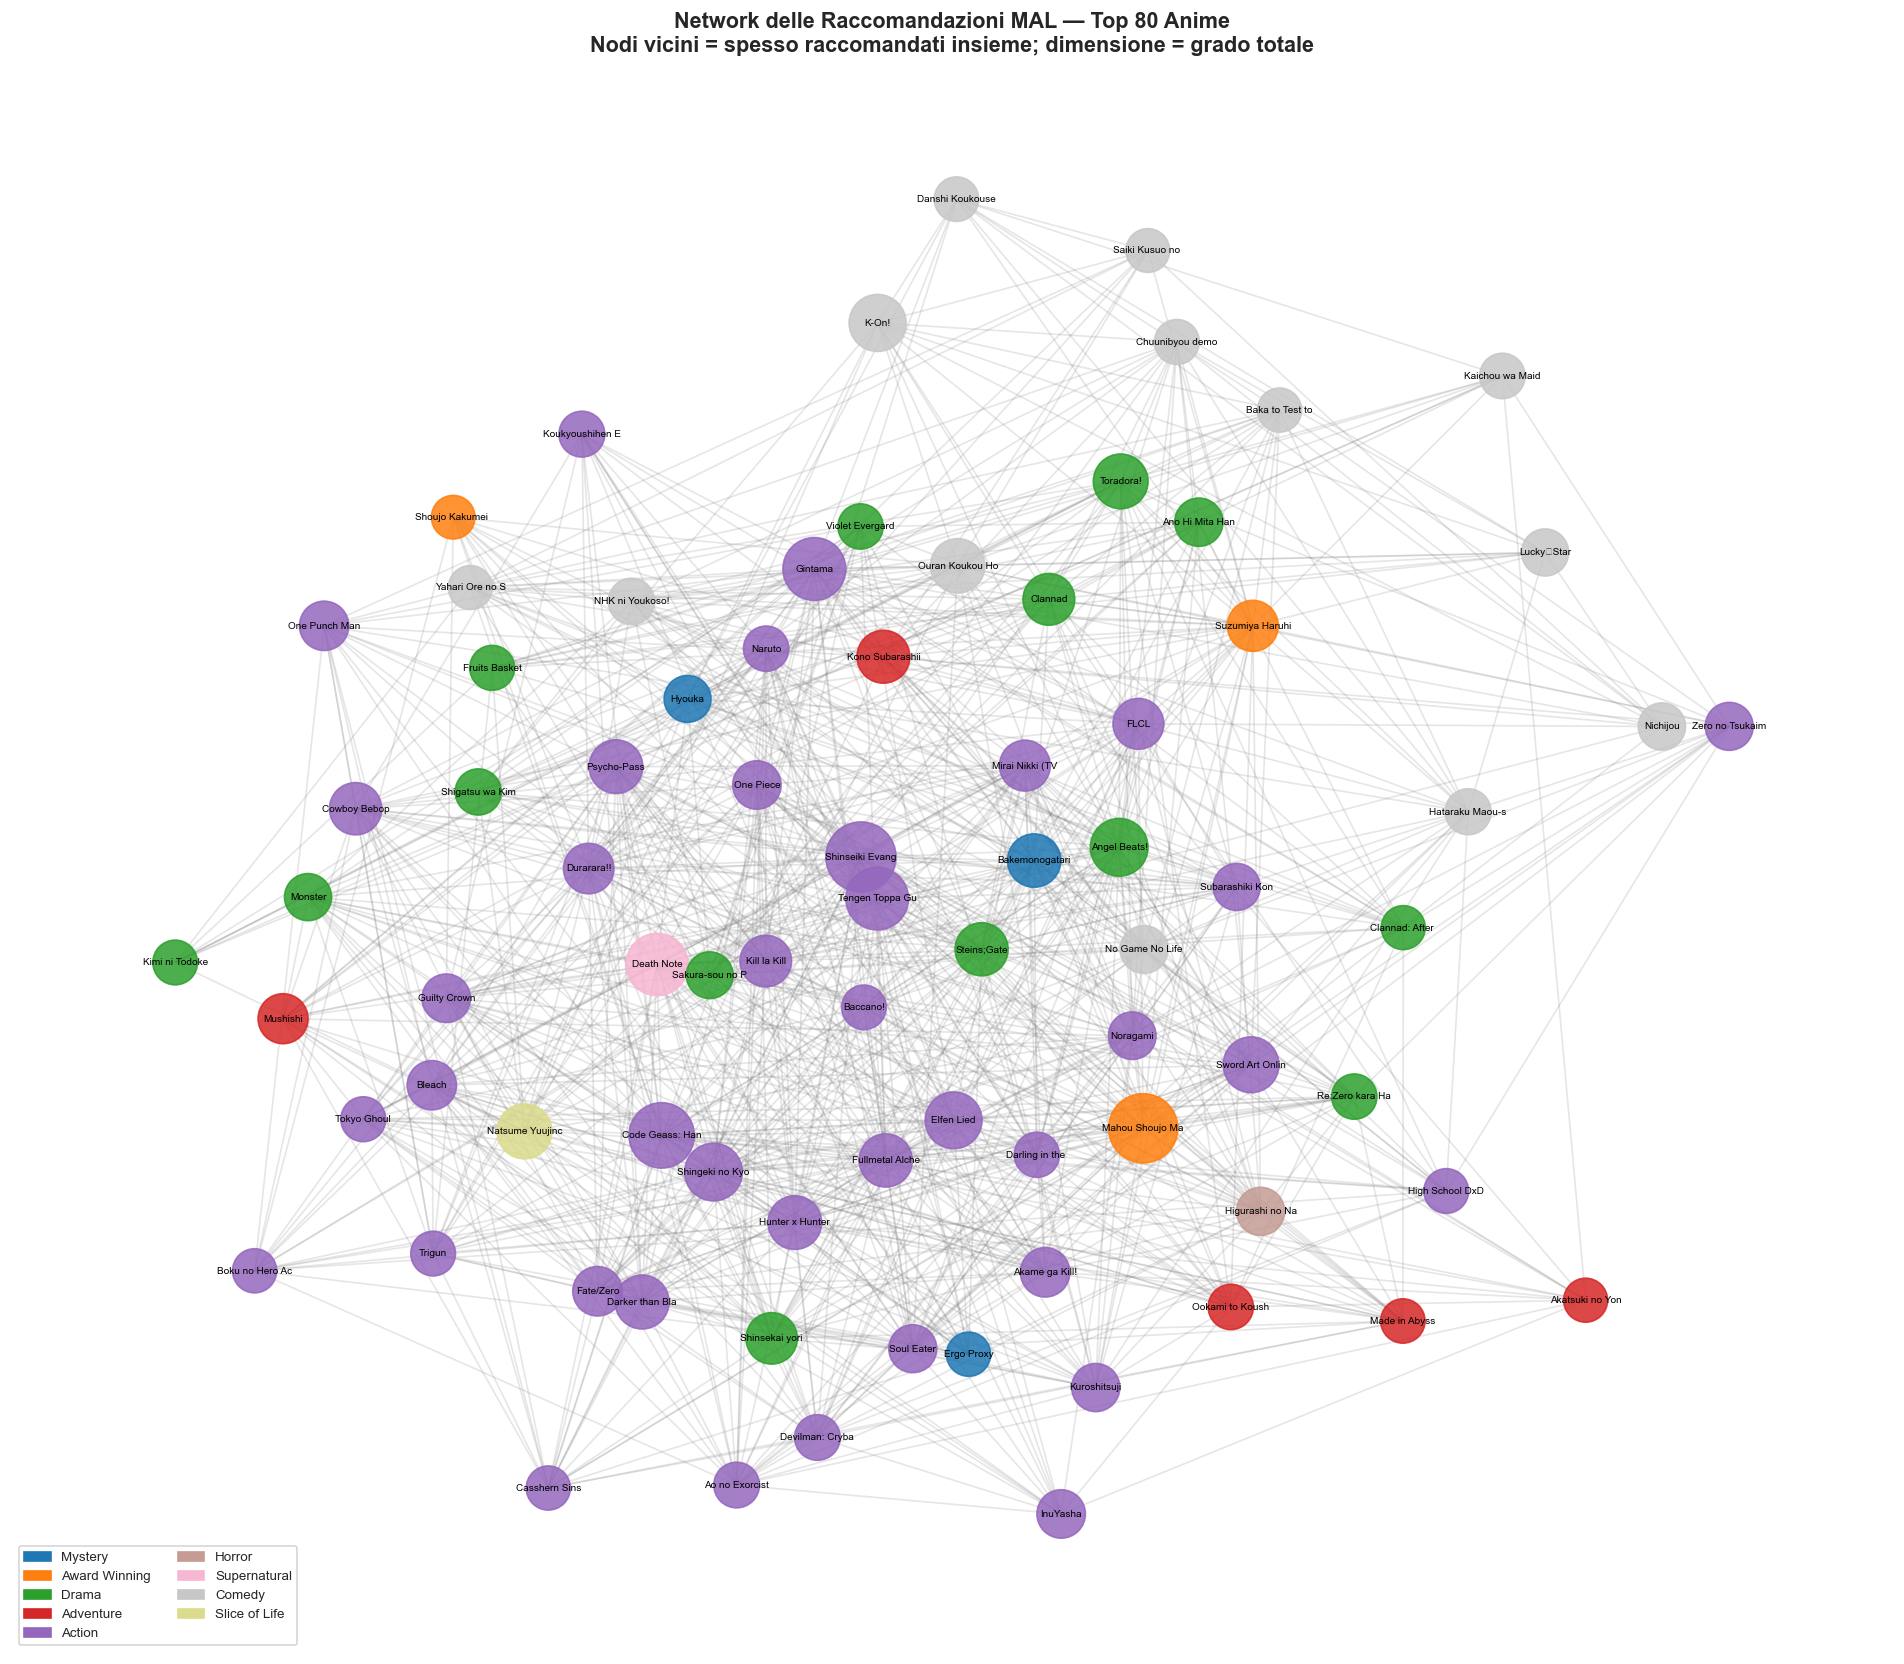

Nodi nel grafo: 80
Archi nel grafo: 1798


In [105]:
TOP_N = 80
top_nodes = degree_df.nlargest(TOP_N, 'total_degree')['mal_id'].tolist()

rec_sub = recs[
    recs['mal_id'].isin(top_nodes) &
    recs['recommendation_mal_id'].isin(top_nodes)
]

G = nx.DiGraph()
G.add_nodes_from(top_nodes)
for _, row in rec_sub.iterrows():
    G.add_edge(row['mal_id'], row['recommendation_mal_id'])

details_ex = (
    details.dropna(subset=['genres'])
    .assign(genre=details['genres'].str[2:-2].str.split("', '"))
    .explode('genre')
)
details_ex = details_ex[details_ex['genre'].str.strip() != ''][['mal_id', 'genre']]
first_genre_net = details_ex.groupby('mal_id')['genre'].first().reset_index()

genre_list   = first_genre_net[first_genre_net['mal_id'].isin(top_nodes)].set_index('mal_id')['genre'].to_dict()
unique_genres = list(set(genre_list.values()))
genre_colors  = {g: plt.cm.tab20(i / len(unique_genres)) for i, g in enumerate(unique_genres)}

node_colors = [genre_colors.get(genre_list.get(n, 'Unknown'), 'gray') for n in G.nodes()]
node_sizes  = [degree_df.set_index('mal_id')['total_degree'].get(n, 1) * 3 for n in G.nodes()]
node_labels = {n: details.set_index('mal_id')['title'].get(n, '')[:15] for n in G.nodes()}

pos = nx.spring_layout(G, k=1.5, seed=42)

fig, ax = plt.subplots(figsize=(16, 14))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, edge_color='gray', arrows=False)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=6)

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in list(genre_colors.items())[:12]]
ax.legend(handles=legend_patches, loc='lower left', fontsize=8, ncol=2, framealpha=0.8)
ax.set_title(f'Network delle Raccomandazioni MAL — Top {TOP_N} Anime\n'
             'Nodi vicini = spesso raccomandati insieme; dimensione = grado totale',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Nodi nel grafo: {G.number_of_nodes()}')
print(f'Archi nel grafo: {G.number_of_edges()}')

#### I ponti tra generi: quale anime unisce mondi diversi?

Un hub può essere hub perché è amato da tutti i fan dello stesso genere — un fenomeno di popolarità interna al cluster. Oppure può essere hub perché viene raccomandato da fan di generi *diversi* — un vero ponte trasversale.

Per distinguere i due casi, costruiamo una metrica di "trasversalità": per ogni anime molto raccomandato, calcoliamo la diversità dei generi degli anime da cui viene raccomandato. Un anime consigliato da soli titoli Action è un hub di nicchia. Un anime consigliato da Action, Romance, Drama, Sci-Fi e Fantasy è un vero ponte culturale.

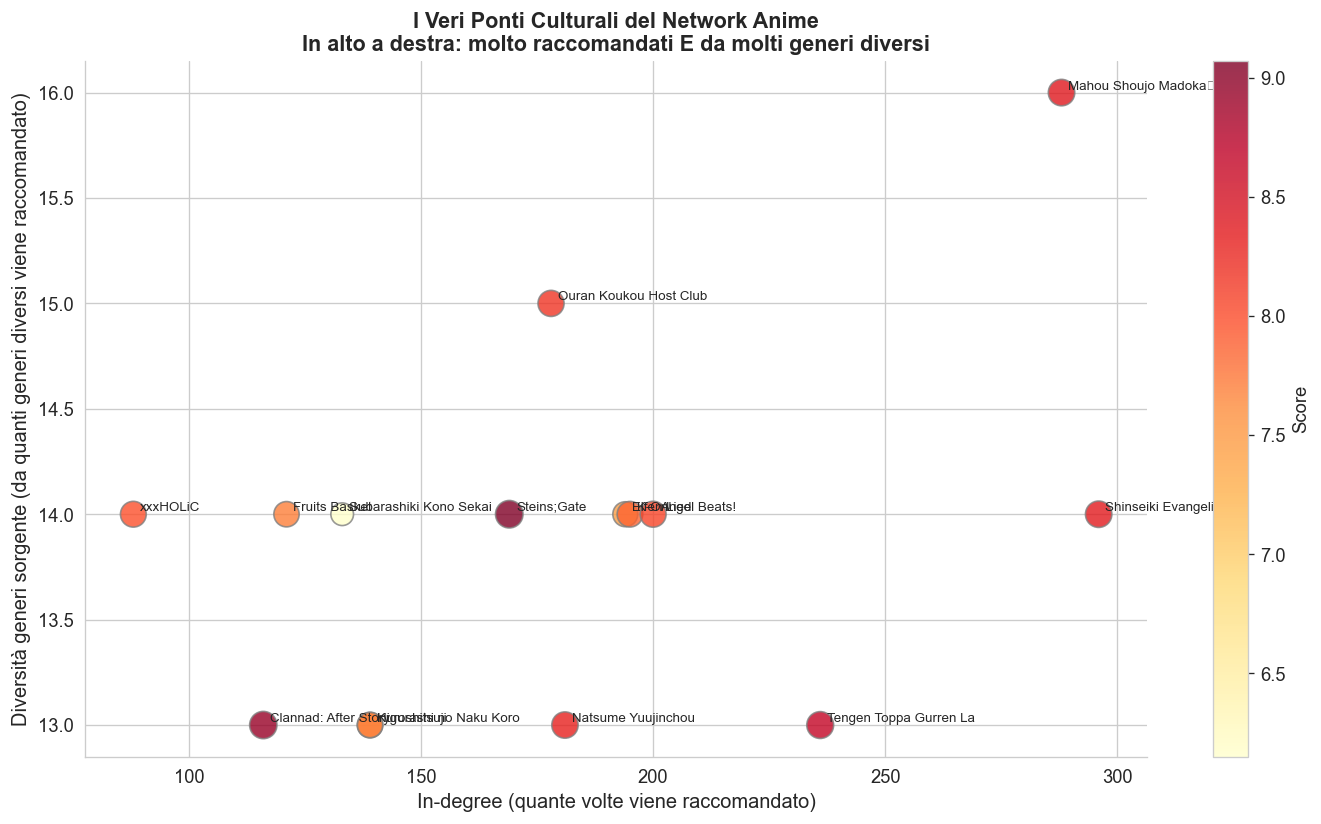

In [106]:
first_genre = (
    details.dropna(subset=['genres'])
    .assign(genre=details['genres'].str[2:-2].str.split("', '"))
    .explode('genre')
)
first_genre = first_genre[first_genre['genre'].str.strip() != ''].groupby('mal_id')['genre'].first().reset_index()

rec_with_genre = (
    recs
    .merge(first_genre.rename(columns={'genre': 'source_genre'}), on='mal_id')
    .merge(first_genre.rename(columns={'mal_id': 'recommendation_mal_id', 'genre': 'target_genre'}),
           on='recommendation_mal_id')
)

genre_diversity = (
    rec_with_genre.groupby('recommendation_mal_id')['source_genre']
    .nunique()
    .reset_index(name='source_genre_diversity')
    .merge(degree_in.rename(columns={'mal_id': 'recommendation_mal_id'}), on='recommendation_mal_id')
    .merge(details[['mal_id', 'title', 'score']], left_on='recommendation_mal_id', right_on='mal_id')
)
genre_diversity = genre_diversity[genre_diversity['in_degree'] >= 10]

top_bridges = genre_diversity.nlargest(15, 'source_genre_diversity')

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(top_bridges['in_degree'], top_bridges['source_genre_diversity'],
                     s=top_bridges['score'].fillna(5) * 30,
                     c=top_bridges['score'], cmap='YlOrRd', alpha=0.8, edgecolors='gray')
plt.colorbar(scatter, ax=ax, label='Score')

for _, row in top_bridges.iterrows():
    ax.annotate(row['title'][:22], (row['in_degree'], row['source_genre_diversity']),
                fontsize=8, xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('In-degree (quante volte viene raccomandato)', fontsize=12)
ax.set_ylabel('Diversità generi sorgente (da quanti generi diversi viene raccomandato)', fontsize=12)
ax.set_title('I Veri Ponti Culturali del Network Anime\n'
             'In alto a destra: molto raccomandati E da molti generi diversi',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

L'analisi del network porta a conclusioni che nessuna classifica tradizionale può offrire. **Gli hub non coincidono sempre con gli anime più popolari**: esistono titoli con audience ridotte che fungono da ponti indispensabili tra generi. I **cluster di gusto** sono reali ma porosi — non un arcipelago di isole separate, ma un continente con confini attraversabili. I **veri ponti culturali** sono i titoli più preziosi per il sistema: anime che parlano a pubblici eterogenei e connettono mondi narrativi distanti.

C'è però un limite strutturale: le raccomandazioni funzionano bene per i titoli popolari, perché molti utenti li hanno visti e possono connetterli. Ma il catalogo contiene migliaia di anime che quasi nessuno ha ancora esplorato — e per questi, la rete di raccomandazioni è quasi vuota. Esistono capolavori che non compaiono in nessuna lista, non perché non valgano, ma perché non abbastanza persone li hanno ancora trovati.

---
## 3. Oltre la mappa conosciuta: i capolavori nascosti

Le raccomandazioni e le classifiche disegnano una mappa densa nella zona dei titoli popolari — ma quella mappa ha bordi bianchi. Gran parte del catalogo anime è territorio inesplorato: titoli prodotti in nicchie, distribuiti in mercati limitati, usciti in anni in cui la comunità internazionale era più piccola, o semplicemente mai finiti nel flusso delle conversazioni mainstream.

MAL permette d'identificare questi titoli con precisione. Un anime con score ≥ 8.0 è — per definizione — considerato eccellente da chi lo ha visto: la media MAL si aggira intorno al 6.4, e superare l'8.0 richiede un consenso positivo significativo. La popolarità si misura con `scored_by` — quante persone hanno effettivamente valutato l'anime — che funziona indipendentemente dalla lunghezza della serie o dal suo stato (in corso o terminato). Un titolo con `scored_by` basso è davvero fuori dal radar, non semplicemente difficile da finire.

I criteri di selezione sono conservativi: score ≥ 8.0, scored_by tra 200 e 5.000. La soglia inferiore garantisce che il punteggio non sia il risultato di un campione troppo piccolo; quella superiore esclude i titoli già conosciuti dalla massa. Il risultato è una lista di destinazioni per chi ha già esaurito i percorsi più battuti.

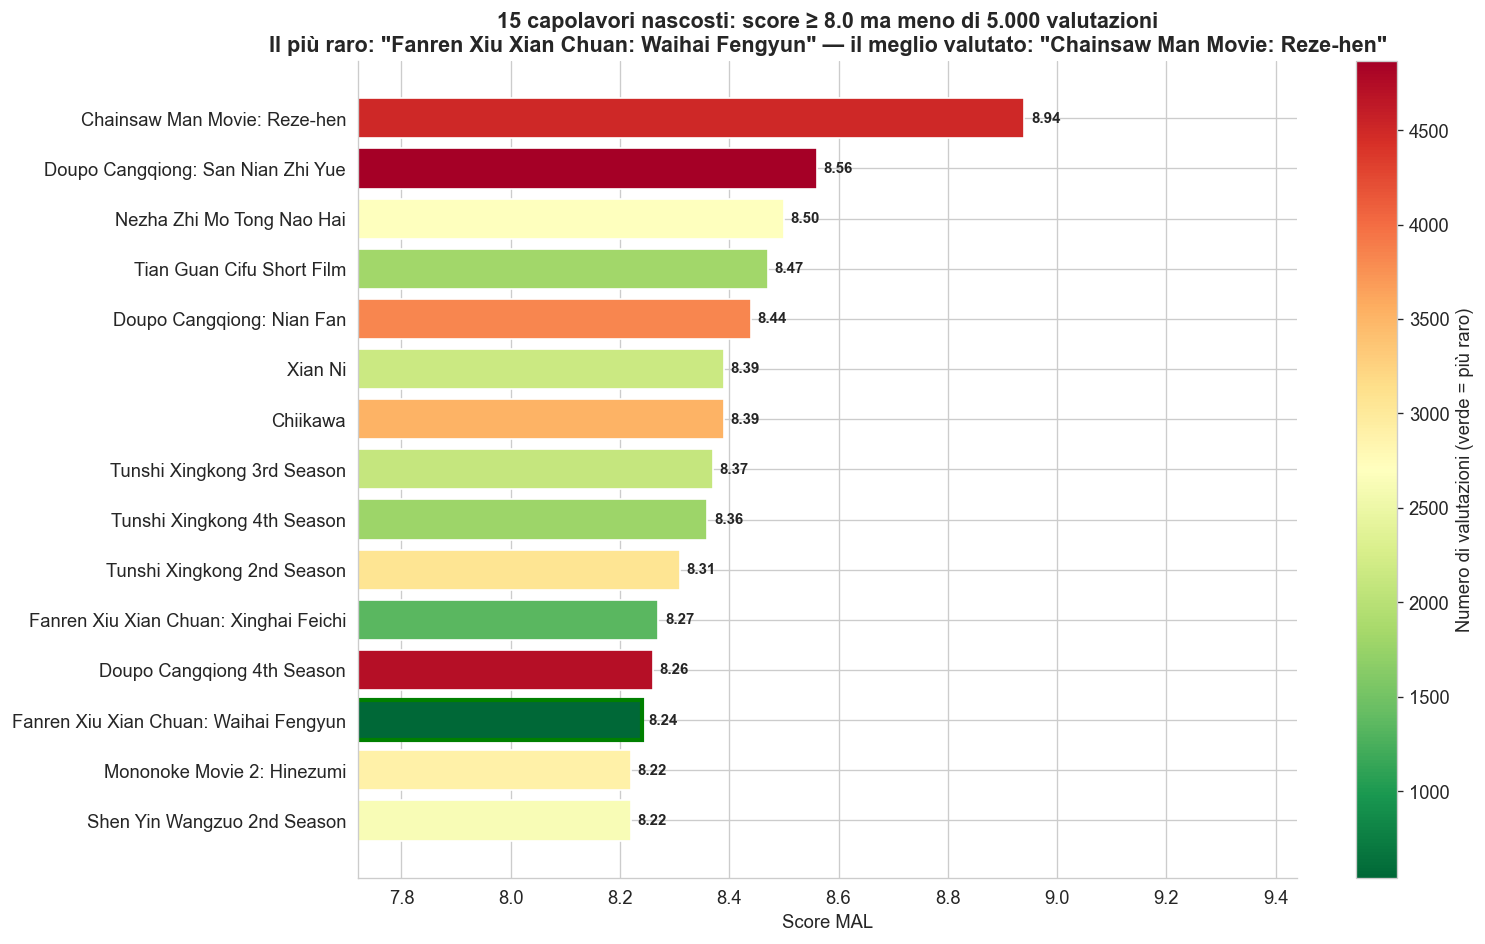

In [107]:
hidden = (
    details
    .query('score >= 8.0 and scored_by >= 200 and scored_by < 5000')
    .sort_values('score', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm   = plt.Normalize(hidden['scored_by'].min(), hidden['scored_by'].max())
colors = plt.cm.RdYlGn_r(norm(hidden['scored_by'].values[::-1]))

rarest  = hidden.loc[hidden['scored_by'].idxmin(), 'title']
best    = hidden.iloc[0]['title']
n_found = len(hidden)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(hidden['title'][::-1], hidden['score'][::-1], color=colors)
ax.bar_label(bars, fmt='%.2f', padding=4, fontweight='bold', fontsize=9)
ax.set_xlabel('Score MAL')
ax.set_xlim(hidden['score'].min() - 0.5, hidden['score'].max() + 0.5)
ax.set_title(
    f'{n_found} capolavori nascosti: score ≥ 8.0 ma meno di 5.000 valutazioni\n'
    f'Il più raro: "{rarest}" — il meglio valutato: "{best}"',
    fontsize=13, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)

rarest_idx = list(hidden['title'][::-1]).index(rarest)
bars[rarest_idx].set_edgecolor('green')
bars[rarest_idx].set_linewidth(2.5)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Numero di valutazioni (verde = più raro)')
plt.tight_layout()
plt.show()

La lista che emerge è una mappa del tesoro per chi vuole navigare oltre il mainstream. Ogni titolo rappresenta un'opera che ha convinto quasi chiunque l'abbia vista — ma che pochissime persone hanno ancora trovato. Il titolo con il minor numero di valutazioni, evidenziato in verde, è la destinazione più remota: il capolavoro più nascosto dell'intero dataset.

Usare `scored_by` invece dei completamenti risolve un problema strutturale importante: serie lunghe ancora in corso come One Piece o Naruto hanno pochissimi "completamenti" semplicemente perché finirle richiede anni — non perché siano sconosciute. `scored_by` cattura invece chiunque abbia guardato abbastanza episodi da esprimere una valutazione, indipendentemente dal formato o dalla lunghezza. Chi appare in questa lista è davvero fuori dal radar.

Finora abbiamo navigato il catalogo esistente — titoli già usciti, già valutati, già connessi. Ma ogni stagione il catalogo si espande: nuovi anime escono ogni tre mesi, e alcuni di essi potrebbero essere le prossime hidden gems prima ancora che qualcuno le scopra. Per intercettarli, serve capire la struttura temporale delle uscite.

---
## 4. Navigare nel tempo: il calendario stagionale delle uscite

Il catalogo anime non è statico: si rinnova ogni tre mesi, seguendo il ritmo delle stagioni giapponesi — Winter, Spring, Summer, Fall. Per un fan che vuole stare al passo, o che vuole intercettare un titolo prima che diventi popolare (e magari scoprire la prossima hidden gem in tempo reale), capire la struttura del calendario è uno strumento di navigazione essenziale.

La domanda è: la distribuzione dei generi tra le stagioni è casuale, o le case di produzione seguono una logica precisa? Se esistono pattern stabili — certi generi che si concentrano in certe stagioni — allora il calendario diventa prevedibile, e un fan può calibrare le aspettative stagione per stagione invece di scoprirlo ogni volta.

La heatmap che segue mostra, per ciascuna combinazione stagione/genere, quanti anime sono stati rilasciati storicamente. I rettangoli blu evidenziano la stagione dominante per i tre generi più prodotti in assoluto.

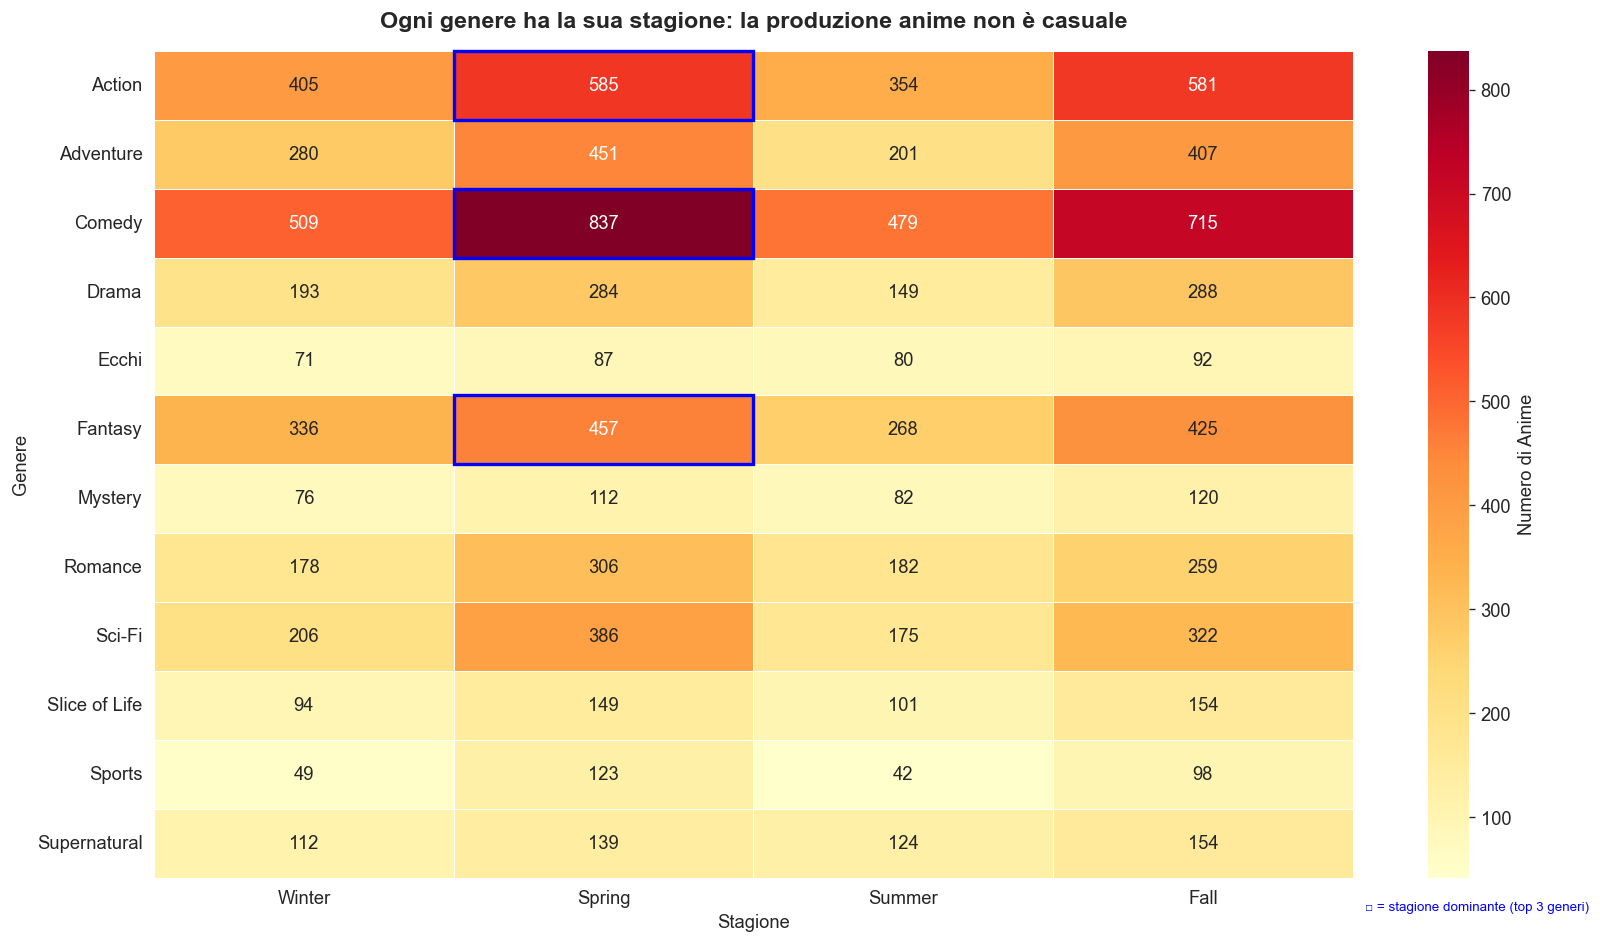

In [108]:
det_genres = details.dropna(subset=['season', 'genres']).copy()
det_genres['genre'] = det_genres['genres'].str[2:-2].str.split("', '")
det_genres = det_genres.explode('genre')
det_genres = det_genres[det_genres['genre'].str.strip() != '']

top_genres   = det_genres['genre'].value_counts().head(12).index
season_order = ['winter', 'spring', 'summer', 'fall']

pivot = (
    det_genres
    .query('genre in @top_genres')
    .groupby(['season', 'genre'])
    .size()
    .unstack(fill_value=0)
    .reindex([s for s in season_order if s in det_genres['season'].unique()])
)
pivot.index = pivot.index.str.capitalize()

# Stagione dominante per ogni genere
dominant_season = pivot.idxmax(axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot.T, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Numero di Anime'}
)
ax.set_title('Ogni genere ha la sua stagione: la produzione anime non è casuale',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Stagione')
ax.set_ylabel('Genere')

# Annota la stagione dominante per i top 3 generi
for genre in list(top_genres)[:3]:
    if genre in pivot.columns:
        row_idx = list(pivot.T.index).index(genre)
        col_idx = list(pivot.index).index(dominant_season[genre])
        ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1,
                     fill=False, edgecolor='blue', lw=2, clip_on=False))

ax.text(1.01, -0.04, '□ = stagione dominante (top 3 generi)',
        transform=ax.transAxes, fontsize=8, color='blue', ha='left')

plt.tight_layout()
plt.show()


La distribuzione non è uniforme — e questo è già di per sé un risultato di navigazione. Esistono generi che si concentrano chiaramente in certe stagioni, il che significa che le case di produzione non rilasciano i titoli a caso: ci sono strategie, tradizioni, e probabilmente decisioni competitive (evitare di competere con titoli simili nella stessa finestra stagionale).

Per un fan, questa mappa ha un'utilità pratica diretta: se segui principalmente un certo genere, sapere in quale stagione tende a concentrarsi ti permette di sapere quando tenere gli occhi aperti e quando aspettarti meno. Le stagioni "povere" per il tuo genere non sono una coincidenza — sono strutturali.

Vale anche la pena notare che il calendario riflette la struttura editoriale giapponese: manga e light novel seguono cicli di pubblicazione che condizionano i tempi di produzione degli anime. Il ritmo stagionale che vediamo è il risultato di una catena produttiva complessa — e conoscerlo significa navigare con cognizione di causa, non affidarsi al caso.

---
## Conclusione: quattro strumenti per orientarsi

Il problema del fandom moderno non è la mancanza di contenuto — è l'eccesso. Con quasi 29.000 titoli catalogati e centinaia di nuove uscite ogni anno, la sfida non è trovare anime da guardare: è trovare *quello giusto per te*, nel momento giusto.

Questo notebook ha proposto quattro strumenti di navigazione complementari, ciascuno utile in una fase diversa del percorso.

La **Hall of Fame** offre i punti di riferimento iniziali: i landmark del catalogo, differenziati tra qualità media e attaccamento emotivo. Le **raccomandazioni del fandom** costruiscono i percorsi tra quei landmark: conoscendo un titolo che ami, puoi muoverti verso ciò che gli assomiglia seguendo il consenso collettivo di chi ha già percorso quel tratto. Le **hidden gems** aprono il territorio inesplorato: capolavori che le classifiche e le raccomandazioni non raggiungono, ma che i dati di MAL permettono d'identificare con precisione. Il **calendario stagionale**, infine, porta la navigazione nel tempo: capire quando e dove si concentrano certi generi significa sapere quando tenere gli occhi aperti per le prossime scoperte.

Nessuno di questi strumenti funziona da solo — è usandoli insieme che si costruisce un percorso di scoperta che va dai titoli universalmente riconosciuti fino alle opere che quasi nessuno ha ancora trovato.

| Strumento di navigazione | A cosa serve |
|---|---|
| Hall of Fame | Trovare i punti di riferimento — i landmark del catalogo |
| Raccomandazioni | Muoversi per connessioni — "ho amato X, cosa guardo dopo?" |
| Hidden Gems | Esplorare oltre il mainstream — capolavori fuori dai radar |
| Calendario stagionale | Navigare nel tempo — sapere quando cercare cosa |